In [1]:
import os
from pathlib import Path

# 現在の作業ディレクトリを確認し、'Scripts' にいる場合は親ディレクトリに移動
current_dir = Path.cwd()
if current_dir.name == "Scripts":
    os.chdir(current_dir.parent)
print(f"Current working directory: {Path.cwd()}")

Current working directory: C:\Users\sryoh\Documents\Python_MSSE_analysis


[保存完了] C:\Users\sryoh\Documents\Python_MSSE_analysis\Results\Plots\Fear_Extinction_Day2_bar.png
[保存完了] C:\Users\sryoh\Documents\Python_MSSE_analysis\Results\Plots\Fear_Extinction_Day2_box.png
=== Contextual Fear Extinction Day 2: anovakun 完全互換 統合統計解析レポート ===

<< 記述統計量 (Descriptive Statistics) >>
Group  n      Mean        SD
  SED  8 73.745833 22.731117
  SED  8 71.256944 24.665383
  SED  8 63.397222 21.442247
  SED  8 60.040278 23.126555
  SED  8 58.918056 30.680362
  LIE  8 28.719444 25.648687
  LIE  8 41.916667 24.086334
  LIE  8 33.820833 15.842007
  LIE  8 45.912500 22.858822
  LIE  8 63.530556 29.961601
  MOE  8 31.816667 17.694340
  MOE  8 35.520833 25.591022
  MOE  8 37.366667 28.708078
  MOE  8 37.700000 33.351139
  MOE  8 35.026389 22.675032

<< 1. 混合二元配置分散分析 (Mixed 2-way ANOVA: Group x Time) >>
     Source           SS  DF1  DF2          MS        F    p_unc      np2      eps
      Group 19563.281243    2   21 9781.640621 6.093332 0.008188 0.367216      NaN
       Time  1030.

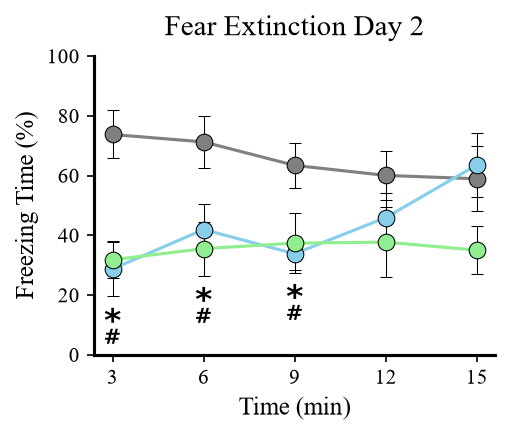

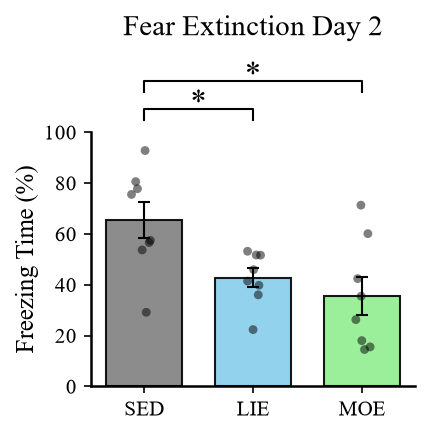

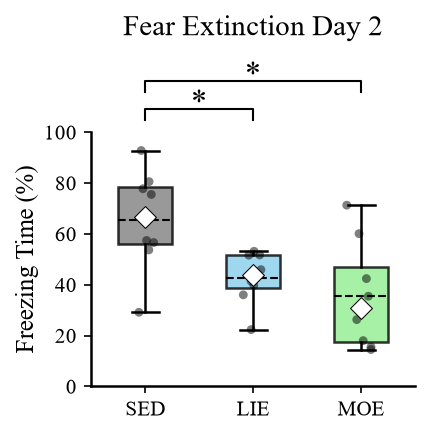

In [2]:
# Fear Extinction Day 2のデータ分析
from pathlib import Path

import matplotlib.pyplot as plt

from Scripts.Create_Dataset import read_freezing_data
from Scripts.Create_Plots import (
    plot_group_bar_jitter_sig,
    plot_group_boxplot_sig,
    plot_save,
)
from Scripts.Statistical_Analysis import generate_anovakun_report

# データの読み込み
data_Ex2 = {}
for type in ["per3", "per15"]:
    data_Ex2[type] = read_freezing_data(
        files=sorted(Path("Ex2").glob("*.xls")),
        type=type
    )

# 折れ線グラフの作成
fig_Ex2, ax_Ex2 = plot_save(
    df=data_Ex2["per3"],
    title = "Fear Extinction Day 2",
    figsize=(3.5, 3),
    save_path=Path("Results/Plots/Fear_Extinction_Day2_per3.png"),
    show_legend=False,
    method="matplotlib"
)

# 棒グラフの作成
fig_bar_Ex2, ax_bar_Ex2 = plot_group_bar_jitter_sig(
    df=data_Ex2["per15"],
    title="Fear Extinction Day 2",
    save_path=Path("Results/Plots/Fear_Extinction_Day2_bar.png"),
    # 有意記号を追加 (x: 0=SED, 1=LIE, 2=MOE)
    sig_brackets=[
        (0, 1, 105, 4, "*"),  # SED vs LIE
        (0, 2, 116, 4, "*"),  # SED vs MOE
    ]
)

# 箱ひげ図の作成
fig_box_Ex2, ax_box_Ex2 = plot_group_boxplot_sig(
    df=data_Ex2["per15"],
    title="Fear Extinction Day 2",
    save_path=Path("Results/Plots/Fear_Extinction_Day2_box.png"),
    # 有意記号を追加 (x: 1=SED, 2=LIE, 3=MOE)
    sig_brackets=[
        (1, 2, 105, 4, "*"),  # SED vs LIE
        (1, 3, 116, 4, "*"),  # SED vs MOE
    ]
)

# 統計解析
generate_anovakun_report(
    data=data_Ex2["per3"],
    title="Contextual Fear Extinction Day 2",
    filename=Path("Anovakun_Like_Analysis_Ex2.txt")
)

# グラフに有意差の記号を追加
# 折れ線グラフに有意差の記号を追加
ax_Ex2.text(3, 5, "*", ha="center", va="bottom", fontsize=16, fontweight="bold")
ax_Ex2.text(6, 12, "*", ha="center", va="bottom", fontsize=16, fontweight="bold")
ax_Ex2.text(9, 13, "*", ha="center", va="bottom", fontsize=16, fontweight="bold") # noqa: F821
ax_Ex2.text(3, 2, "#", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax_Ex2.text(6, 9, "#", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax_Ex2.text(9, 10, "#", ha="center", va="bottom", fontsize=10, fontweight="bold") # noqa: F821

fig_Ex2.savefig(
    r"Results\Plots\Extinction_day2_per3_sig.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
